# BigBasket Data Cleaning & Analysis

## Step 1: Initial Raw Data Inspection

The raw BigBasket order data is loaded before cleaning. This step checks the initial size and structure of the orders and products datasets.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("orders_raw.csv")
products = pd.read_csv("products.csv")

print("Orders shape:", orders.shape)
print("Products shape:", products.shape)

print("\nOrders information:")
orders.info()

Orders shape: (508, 11)
Products shape: (31, 5)

Orders information:
<class 'pandas.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_id       508 non-null    int64  
 1   order_date     508 non-null    str    
 2   customer_name  508 non-null    str    
 3   city           508 non-null    str    
 4   category       508 non-null    str    
 5   product_id     508 non-null    int64  
 6   quantity       508 non-null    int64  
 7   amount_inr     498 non-null    float64
 8   payment_mode   508 non-null    str    
 9   status         508 non-null    str    
 10  rating         439 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 43.8 KB


In [2]:
before_rows = len(orders)

orders = orders.drop_duplicates(subset="order_id", keep="first").copy()

after_rows = len(orders)
removed_rows = before_rows - after_rows

print("Rows before duplicate removal:", before_rows)
print("Rows after duplicate removal:", after_rows)
print("Duplicate rows removed:", removed_rows)

Rows before duplicate removal: 508
Rows after duplicate removal: 500
Duplicate rows removed: 8


In [3]:
orders["city"] = orders["city"].str.strip().str.title()
orders["category"] = orders["category"].str.strip().str.title()

print("Distinct cities:")
print(sorted(orders["city"].unique()))

print("\nDistinct categories:")
print(sorted(orders["category"].unique()))

print("\nNumber of distinct cities:", orders["city"].nunique())
print("Number of distinct categories:", orders["category"].nunique())

Distinct cities:
['Bengaluru', 'Hyderabad', 'Mumbai', 'Pune']

Distinct categories:
['Bakery', 'Dairy & Eggs', 'Fruits & Vegetables', 'Household Essentials', 'Personal Care', 'Snacks & Beverages']

Number of distinct cities: 4
Number of distinct categories: 6


In [4]:
missing_amount = orders["amount_inr"].isna().sum()

print("Missing amount_inr values:", missing_amount)

print("\nMissing rating values by status:")
print(orders.loc[orders["rating"].isna(), "status"].value_counts())

print("\nRating values are left as null because they are legitimate for Cancelled and Pending orders.")

Missing amount_inr values: 10

Missing rating values by status:
status
Cancelled    42
Pending      24
Name: count, dtype: int64

Rating values are left as null because they are legitimate for Cancelled and Pending orders.


In [5]:
delivered = orders[
    (orders["status"] == "Delivered") &
    (orders["amount_inr"].notna())
].copy()

Q1 = delivered["amount_inr"].quantile(0.25)
Q3 = delivered["amount_inr"].quantile(0.75)
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

outliers = delivered[
    delivered["amount_inr"] > upper_fence
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower fence:", lower_fence)
print("Upper fence:", upper_fence)
print("Number of upper outliers:", len(outliers))

Q1: 90.0
Q3: 275.0
IQR: 185.0
Lower fence: -187.5
Upper fence: 552.5
Number of upper outliers: 16


In [6]:
outlier_count = (delivered["amount_inr"] > upper_fence).sum()

orders.loc[
    (orders["status"] == "Delivered") & orders["amount_inr"].notna(),
    "amount_inr"
] = orders.loc[
    (orders["status"] == "Delivered") & orders["amount_inr"].notna(),
    "amount_inr"
].clip(upper=upper_fence)

print("Number of rows capped:", outlier_count)
print("Upper fence used for capping:", upper_fence)

Number of rows capped: 16
Upper fence used for capping: 552.5


In [7]:
orders["order_date"] = pd.to_datetime(orders["order_date"])

orders["month"] = orders["order_date"].dt.to_period("M").astype(str)
orders["month_name"] = orders["order_date"].dt.month_name()

orders["revenue_per_unit"] = orders["amount_inr"] / orders["quantity"]

orders["is_delivered"] = orders["status"].eq("Delivered")

print("Date and analysis columns created successfully.")
print(orders[["order_date", "month", "month_name", "revenue_per_unit", "is_delivered"]].head())

Date and analysis columns created successfully.
  order_date    month month_name  revenue_per_unit  is_delivered
0 2026-03-09  2026-03      March              35.0          True
1 2026-05-22  2026-05        May              60.0          True
2 2026-06-30  2026-06       June              75.0          True
3 2026-03-01  2026-03      March              30.0          True
4 2026-04-05  2026-04      April             110.0          True


In [8]:
category_revenue = (
    orders[orders["is_delivered"] & orders["amount_inr"].notna()]
    .groupby("category")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by category:")
print(category_revenue)

print("\nTop category:", category_revenue.idxmax())
print("Top category revenue:", category_revenue.max())

Revenue by category:
category
Household Essentials    20910.0
Bakery                  14975.0
Personal Care           14594.5
Dairy & Eggs            13675.0
Snacks & Beverages      11312.5
Fruits & Vegetables      9170.0
Name: amount_inr, dtype: float64

Top category: Household Essentials
Top category revenue: 20910.0


In [9]:
supplier_data = pd.merge(
    orders,
    products[["product_id", "supplier"]],
    on="product_id",
    how="left"
)

supplier_revenue = (
    supplier_data[
        (supplier_data["is_delivered"]) &
        (supplier_data["amount_inr"].notna())
    ]
    .groupby("supplier")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

print("Revenue by supplier:")
print(supplier_revenue)

print("\nTop supplier:", supplier_revenue.idxmax())
print("Top supplier revenue:", supplier_revenue.max())

Revenue by supplier:
supplier
HomeEssentials Traders    20910.0
BakeHouse Supplies        18550.0
CarePlus Distributors     14594.5
DairyBest Ltd             10710.0
SnackHub India             7737.5
FreshFarms Co              5490.0
GreenValley Traders        3680.0
CountryEggs Farms          2965.0
Name: amount_inr, dtype: float64

Top supplier: HomeEssentials Traders
Top supplier revenue: 20910.0


In [10]:
print("Cross-validation:")
print("Top category from orders:", category_revenue.idxmax())
print("Top category revenue:", category_revenue.max())

print("Top supplier from merged data:", supplier_revenue.idxmax())
print("Top supplier revenue:", supplier_revenue.max())

Cross-validation:
Top category from orders: Household Essentials
Top category revenue: 20910.0
Top supplier from merged data: HomeEssentials Traders
Top supplier revenue: 20910.0


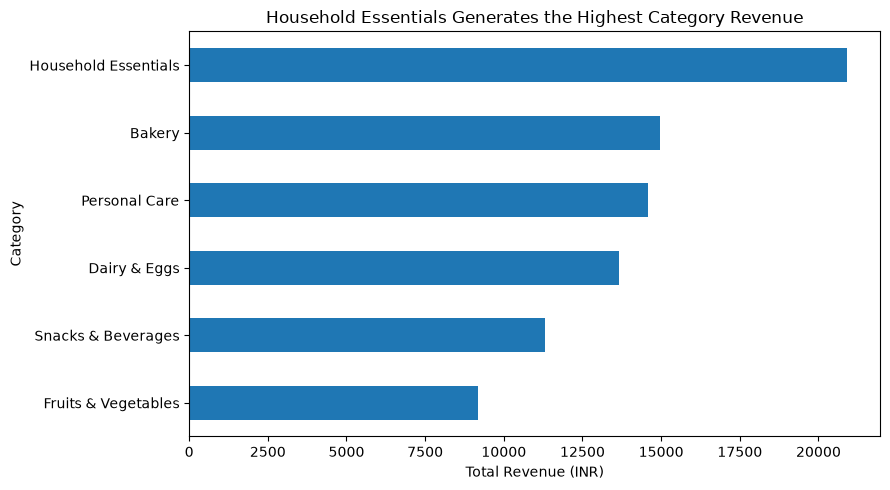

In [11]:
# Chart 1: Revenue by Category

plt.figure(figsize=(9, 5))

category_revenue.sort_values().plot(kind="barh")

plt.title("Household Essentials Generates the Highest Category Revenue")
plt.xlabel("Total Revenue (INR)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

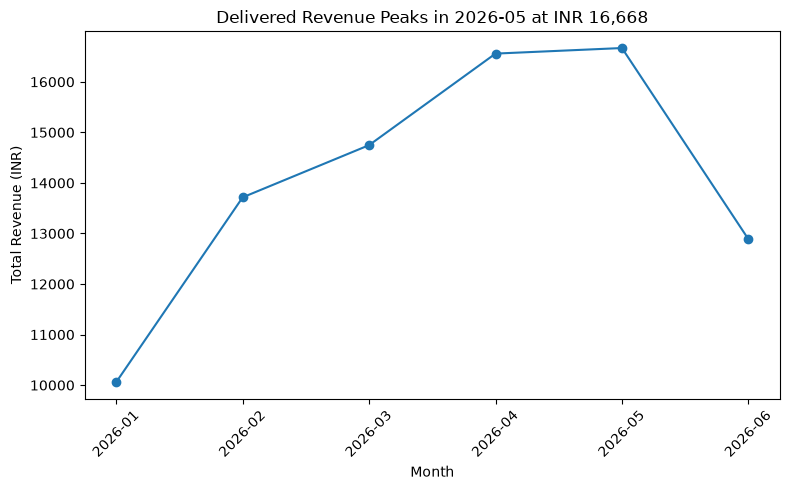

In [13]:
# Chart 2: Monthly Revenue Trend for Delivered Orders

monthly_revenue = (
    orders[orders["is_delivered"]]
    .groupby("month")["amount_inr"]
    .sum()
    .sort_index()
)

highest_month = monthly_revenue.idxmax()
highest_revenue = monthly_revenue.max()

plt.figure(figsize=(8, 5))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker="o")

plt.title(
    f"Delivered Revenue Peaks in {highest_month} at INR {highest_revenue:,.0f}"
)
plt.xlabel("Month")
plt.ylabel("Total Revenue (INR)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

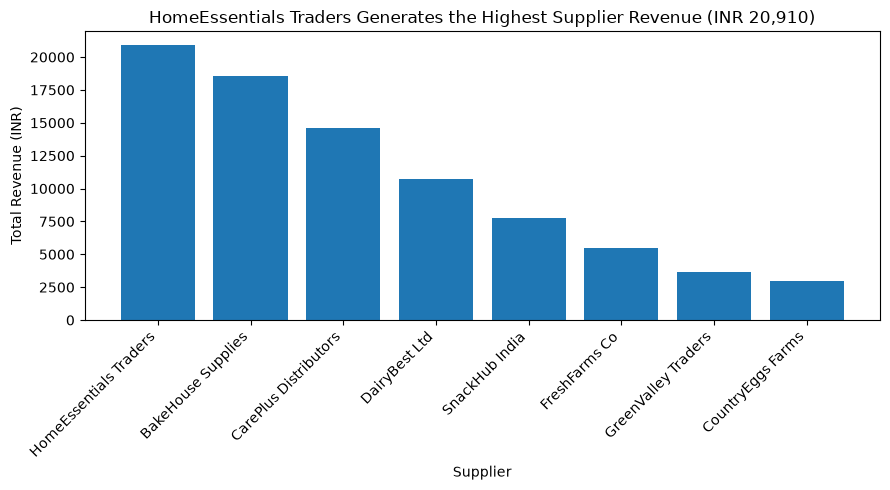

In [14]:
# Chart 3: Revenue by Supplier

supplier_revenue = (
    supplier_revenue
    .sort_values(ascending=False)
)

top_supplier = supplier_revenue.idxmax()
top_supplier_revenue = supplier_revenue.max()

plt.figure(figsize=(9, 5))
plt.bar(supplier_revenue.index, supplier_revenue.values)

plt.title(
    f"{top_supplier} Generates the Highest Supplier Revenue "
    f"(INR {top_supplier_revenue:,.0f})"
)
plt.xlabel("Supplier")
plt.ylabel("Total Revenue (INR)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Task 9: Key Observations

### Observation 1
**What:** Household Essentials generated the highest category revenue at INR 20,910.

**Why it matters:** This category is the strongest revenue contributor in the cleaned delivered-order data.

**Next step:** Focus on maintaining product availability and exploring opportunities to grow this category further.

### Observation 2
**What:** HomeEssentials Traders generated the highest supplier revenue at INR 20,910.

**Why it matters:** This supplier is the largest contributor to revenue among the suppliers in the analysis.

**Next step:** Monitor stock availability and supplier performance to maintain consistent sales.

### Observation 3
**What:** The IQR analysis identified 16 upper outlier rows among delivered orders, and these values were capped at the upper fence of INR 552.5.

**Why it matters:** Capping reduces the influence of unusually high order amounts while keeping the affected orders in the dataset.

**Next step:** Continue monitoring high-value delivered orders to determine whether they represent genuine large purchases or unusual transactions.